### For_POLDR pytorch 验证训练情况

In [1]:
import pyarrow.parquet as pq
data_path = '/media/amers/WHX/polder_simulation_results/train_data_polder_0.5.parquet'
data = pq.read_table(data_path).to_pandas()
data

FileNotFoundError: /media/amers/WHX/polder_simulation_results/train_data_polder_0.5.parquet

1. Loading and splitting data...
Test set shape: Features (1308815, 15), Targets (1308815, 9)

2. Loading feature scaler and transforming test data...
Feature scaler loaded from '/media/amers/SSD_part1/whx/ResNet_code/forward/V1//scalers/scaler_features.pkl'

3. Initializing 3x3 academic figure grid...
--------------------------------------------------
Validating Wavelength: 0.443
Using device: cuda
Model loaded from /media/amers/SSD_part1/whx/ResNet_code/forward/V1//models/dnn_model_0.443.pth
  - Reflectance: R2 Score = 0.999963, RMSE = 0.000636, MAE = 0.000400
--------------------------------------------------
Validating Wavelength: 0.49
Using device: cuda
Model loaded from /media/amers/SSD_part1/whx/ResNet_code/forward/V1//models/dnn_model_0.49.pth
  - Reflectance: R2 Score = 0.999960, RMSE = 0.000719, MAE = 0.000439
  - DOLP: R2 Score = 0.999940, RMSE = 0.000821, MAE = 0.000565
--------------------------------------------------
Validating Wavelength: 0.565
Using device: cuda
Model 

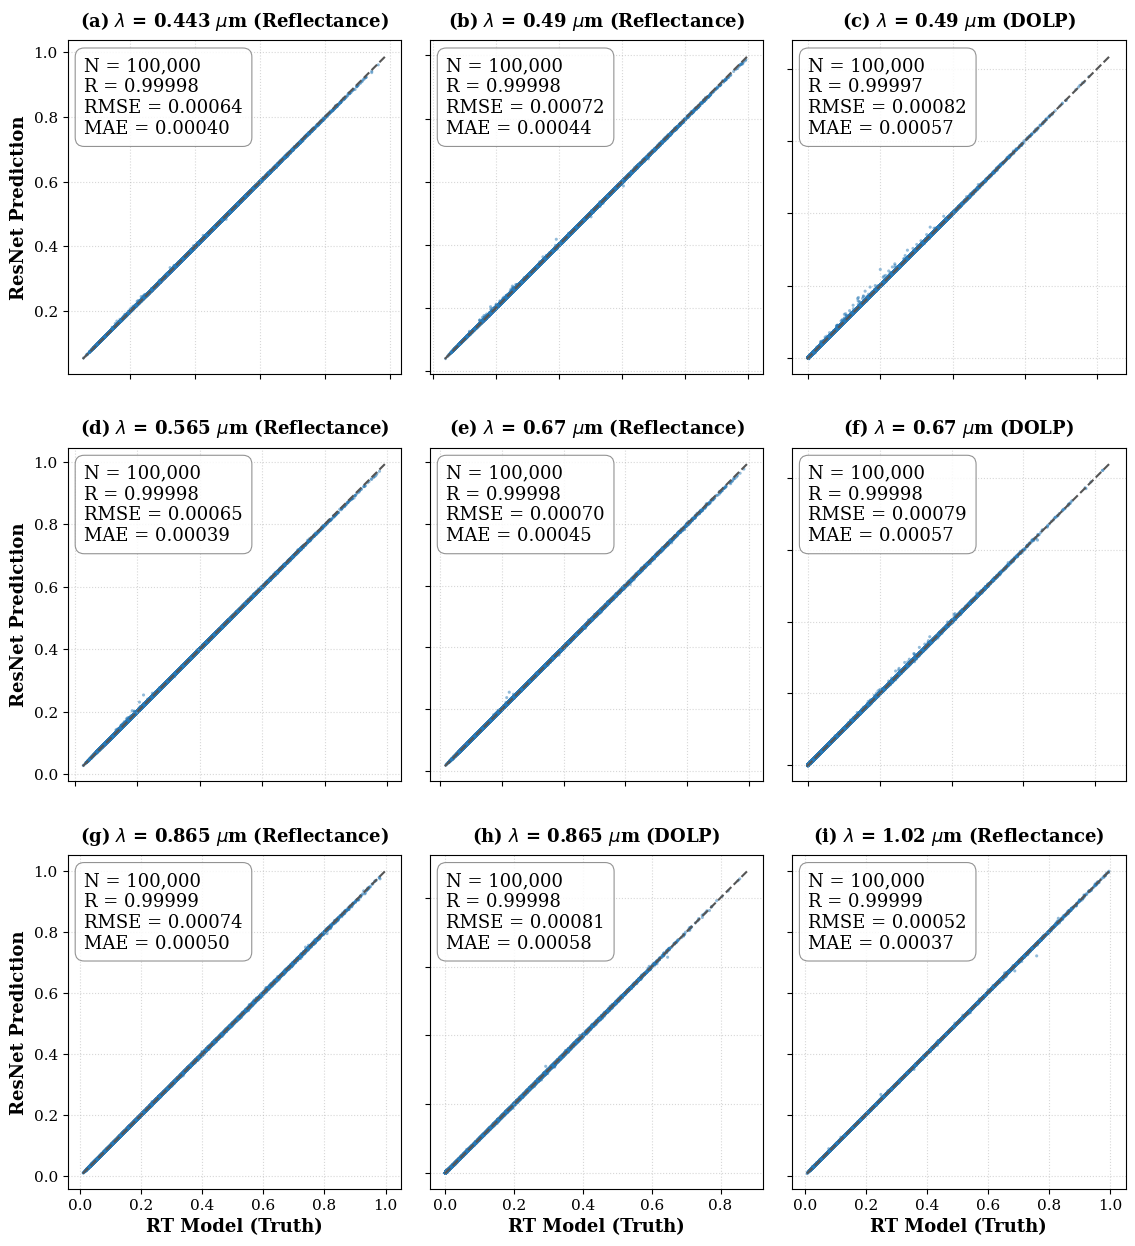

In [9]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import pyarrow.parquet as pq
import torch
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

# 导入您自定义的PyTorch模型类
from ResNet_RTModel_pytorch import DNNModel

# ========================
# 参数配置
# ========================
feature_columns = [
    "sza",
    "vza",
    "fis",
    "vc_BB",
    "vc_Urban",
    "vc_Ocean",
    "vc_Dust",
    "ALH",
    "BRDF1",
    "k1",
    "k2",
    "BPDF",
    "o3",
    "h2o",
    "dem",
]

output_columns = ["Reflectance", "DOLP"]
wavelengths = ["0.443", "0.49", "0.565", "0.67", "0.865", "1.02"]

BASE_PATH = "/media/amers/SSD_part1/whx/ResNet_code/forward/V1/"

# ========================
# 1. 读取数据并划分测试集
# ==============================================================================
print("1. Loading and splitting data...")
data_path = "/media/amers/WHX/polder_simulation_results/V1版数据集/train_data_polder_0.5.parquet"
data = pq.read_table(data_path).to_pandas()

all_target_cols = []
polarization_flag = [0, 1, 0, 1, 1, 0]
for i, wl in enumerate(wavelengths):
    all_target_cols.append(f"{wl}_Reflectance")
    if polarization_flag[i] == 1:
        all_target_cols.append(f"{wl}_DOLP")

X_all = data[feature_columns].values
y_all = data[all_target_cols].values

_, X_test, _, y_test_all = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)
print(f"Test set shape: Features {X_test.shape}, Targets {y_test_all.shape}")


# ========================
# 2. 加载特征缩放器并对测试集特征进行缩放
# ==============================================================================
print("\n2. Loading feature scaler and transforming test data...")
try:
    scaler_features_path = f"{BASE_PATH}/scalers/scaler_features.pkl"
    scaler_features = joblib.load(scaler_features_path)
    X_test_scaled = scaler_features.transform(X_test)
    print(f"Feature scaler loaded from '{scaler_features_path}'")
except FileNotFoundError:
    print(f"[错误] 找不到特征缩放器文件: '{scaler_features_path}'")
    exit()

# ========================
# 3. 创建 3x3 论文级多子图画布
# ==============================================================================
print("\n3. Initializing 3x3 academic figure grid...")
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(12, 12.5))
axes_flat = axes.flatten()
plt.rcParams.update({"font.size": 11, "font.family": "serif"})

mae_dict = {col: [] for col in output_columns}
rmse_dict = {col: [] for col in output_columns}
r2_dict = {col: [] for col in output_columns}

target_col_idx = 0
plot_idx = 0  # 追踪当前画到了第几个子图

# 逐波长执行验证与绘图
for i, wl in enumerate(wavelengths):
    print("-" * 50)
    print(f"Validating Wavelength: {wl}")

    # 加载模型
    try:
        model_path = f"{BASE_PATH}/models/dnn_model_{wl}.pth"
        model = DNNModel.load_model(model_path)
        model.eval()
    except FileNotFoundError:
        print(f"[警告] 找不到模型文件: {model_path}，跳过此波长。")
        num_outputs = 2 if polarization_flag[i] else 1
        target_col_idx += num_outputs
        continue

    num_outputs = model.output_dim
    y_test_current = y_test_all[:, target_col_idx : target_col_idx + num_outputs]

    scaler_y_path = f"{BASE_PATH}/scalers/scaler_y_{wl}.pkl"
    scaler_y = joblib.load(scaler_y_path)

    y_pred_scaled = model.predict(X_test_scaled)
    y_pred = scaler_y.inverse_transform(y_pred_scaled)
    y_true = y_test_current

    current_output_cols = ["Reflectance"]
    if num_outputs == 2:
        current_output_cols.append("DOLP")

    for j, col in enumerate(current_output_cols):
        ax = axes_flat[plot_idx]

        r2 = r2_score(y_true[:, j], y_pred[:, j])
        rmse = np.sqrt(np.mean((y_pred[:, j] - y_true[:, j]) ** 2))
        mae = np.mean(np.abs(y_pred[:, j] - y_true[:, j]))

        mae_dict[col].append(mae)
        rmse_dict[col].append(rmse)
        r2_dict[col].append(r2)

        print(
            f"  - {col}: R2 Score = {r2:.6f}, RMSE = {rmse:.6f}, MAE = {mae:.6f}"
        )

        # 散点点数降采样，加速渲染并降低SVG/PDF导出体积
        np.random.seed(42)
        sample_indices = np.random.choice(
            len(y_true), min(len(y_true), 100000), replace=False
        )

        ax.scatter(
            y_true[sample_indices, j],
            y_pred[sample_indices, j],
            alpha=0.5,
            s=5,
            color="#2878b5",
            edgecolors="none",
            rasterized=True,
        )

        # 1:1 虚线绘制
        min_val = min(y_true[:, j].min(), y_pred[:, j].min())
        max_val = max(y_true[:, j].max(), y_pred[:, j].max())
        ax.plot(
            [min_val, max_val],
            [min_val, max_val],
            color="#555555",
            linestyle="--",
            linewidth=1.5,
        )

        # === 【修改点】：根据子图位置，条件过滤横纵轴标签 ===
        # 1. 横坐标 (X轴) 仅展示在最底下一行 (子图索引 6, 7, 8)
        if plot_idx >= 6:
            ax.set_xlabel("RT Model (Truth)", fontsize=13, fontweight="bold")
        else:
            ax.set_xticklabels([])  # 隐藏其他行的X轴刻度数值以保持界面清爽

        # 2. 纵坐标 (Y轴) 仅展示在最左侧一列 (子图索引 0, 3, 6)
        if plot_idx % 3 == 0:
            ax.set_ylabel("ResNet Prediction", fontsize=13, fontweight="bold")
        else:
            ax.set_yticklabels([])  # 隐藏其他列的Y轴刻度数值

        # 子图标题 (a) - (i)
        sub_label = chr(97 + plot_idx)
        ax.set_title(
            f"({sub_label}) $\lambda$ = {wl} $\mu$m ({col})",
            fontsize=13,
            fontweight="bold",
            pad=10,
        )

        # 统计文本框设置
        r_coeff = np.sqrt(r2) if r2 >= 0 else 0.0
        stats_text = "\n".join(
            (
                f"N = {len(sample_indices):,}",
                f"R = {r_coeff:.5f}",
                f"RMSE = {rmse:.5f}",
                f"MAE = {mae:.5f}",
            )
        )
        props = dict(
            boxstyle="round,pad=0.5",
            facecolor="white",
            alpha=0.85,
            edgecolor="gray",
            lw=0.8,
        )
        ax.text(
            0.05,
            0.95,
            stats_text,
            transform=ax.transAxes,
            fontsize=13,  # 微调统计框字体大小使其更清晰
            verticalalignment="top",
            bbox=props,
        )

        ax.tick_params(labelsize=11)
        ax.grid(True, linestyle=":", alpha=0.5)
        ax.set_aspect("equal", adjustable="box")

        plot_idx += 1

    target_col_idx += num_outputs

# ========================
# 4. 图表保存与导出
# ==============================================================================
# 使用 tight_layout 自动优化间距，并通过 subplots_adjust 进一步收紧，使画面非常紧凑
plt.tight_layout()
plt.subplots_adjust(hspace=0.22, wspace=-0.05)

output_img_path = os.path.join(
    BASE_PATH, "validation_resnet_forward_3x3_academic.png"
)
plt.savefig(output_img_path, dpi=300, bbox_inches="tight", facecolor="white")
print(f"\n验证完成。学术级大图成功保存至: {output_img_path}")

plt.show()